# Visualization draft — where the VaR misses
Realised returns (grey) with predicted VaR (coloured) and **exceptions marked as low-opacity red dots** (days where the realised return fell below the VaR). Fixed n_states = 2 (except cases 5–6), α = 0.05.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start=None):
    """Walk up from the working dir to the folder containing pyproject.toml."""
    p = (start or Path.cwd()).resolve()
    for d in [p, *p.parents]:
        if (d / "pyproject.toml").exists():
            return d
    raise RuntimeError("project root (pyproject.toml) not found")

PROJECT_ROOT = find_project_root()
FEATURES_DIR = PROJECT_ROOT / "artifacts" / "features"
ALPHA = 0.05

RET_COLOR = "#555555"
MSM_COLOR = "#e06c00"
GMM_COLOR = "#9b30d9"
MSM5_COLOR = "#0077b6"
GMM5_COLOR = "#1a9e3f"
EXC_COLOR = "red"

from ms_var_prediction.backtester import Backtester
from ms_var_prediction.pipeline import features as fs
from ms_var_prediction.utils import gaussian_mixture_cdf, quantile_bisection

# Each case: (title, [ (ticker, feat_file, model, n, colour, label), ... ])
CASES = [
    ("Case 1 — both models: binomial passes, independence fails (BAC)", [
        ("BAC", "msm_n2.csv", "msm", 2, MSM_COLOR, "MSM n=2"),
        ("BAC", "gmm_n2.csv", "gmm", 2, GMM_COLOR, "GMM n=2")]),
    ("Case 2 — independence passes but binomial fails  (2a MSM: IBM, 2b GMM: INTC)", [
        ("IBM", "msm_n2.csv", "msm", 2, MSM_COLOR, "MSM n=2"),
        ("INTC", "gmm_n2.csv", "gmm", 2, GMM_COLOR, "GMM n=2")]),
    ("Case 3 — MSM passes both, GMM does not (AAPL)", [
        ("AAPL", "msm_n2.csv", "msm", 2, MSM_COLOR, "MSM n=2"),
        ("AAPL", "gmm_n2.csv", "gmm", 2, GMM_COLOR, "GMM n=2")]),
    ("Case 4 — GMM passes both, MSM does not (EBAY)", [
        ("EBAY", "gmm_n2.csv", "gmm", 2, GMM_COLOR, "GMM n=2"),
        ("EBAY", "msm_n2.csv", "msm", 2, MSM_COLOR, "MSM n=2")]),
    ("Case 5 — MSM n=2 passes both, MSM n=5 does not (NVDA)", [
        ("NVDA", "msm_n2.csv", "msm", 2, MSM_COLOR, "MSM n=2"),
        ("NVDA", "msm_n5.csv", "msm", 5, MSM5_COLOR, "MSM n=5")]),
    ("Case 6 — GMM n=2 passes both, GMM n=5 does not (AMD)", [
        ("AMD", "gmm_n2.csv", "gmm", 2, GMM_COLOR, "GMM n=2"),
        ("AMD", "gmm_n5.csv", "gmm", 5, GMM5_COLOR, "GMM n=5")]),
]

In [2]:
# Load only the rows we need from each (large) features file, via chunks.
need = {}
for _, panels in CASES:
    for tk, f, *_ in panels:
        need.setdefault(f, set()).add(tk)

feat = {}
for f, tickers in need.items():
    parts = []
    for chunk in pd.read_csv(FEATURES_DIR / f, chunksize=200_000):
        parts.append(chunk[chunk['ticker'].isin(tickers)])
    feat[f] = pd.concat(parts, ignore_index=True)
    print(f, '->', dict(feat[f]['ticker'].value_counts()))

msm_n2.csv -> {'AAPL': np.int64(3771), 'NVDA': np.int64(3771), 'BAC': np.int64(3771), 'IBM': np.int64(3771), 'EBAY': np.int64(3771)}


gmm_n2.csv -> {'AAPL': np.int64(3771), 'AMD': np.int64(3771), 'BAC': np.int64(3771), 'INTC': np.int64(3771), 'EBAY': np.int64(3771)}


msm_n5.csv -> {'NVDA': np.int64(3771)}


gmm_n5.csv -> {'AMD': np.int64(3771)}


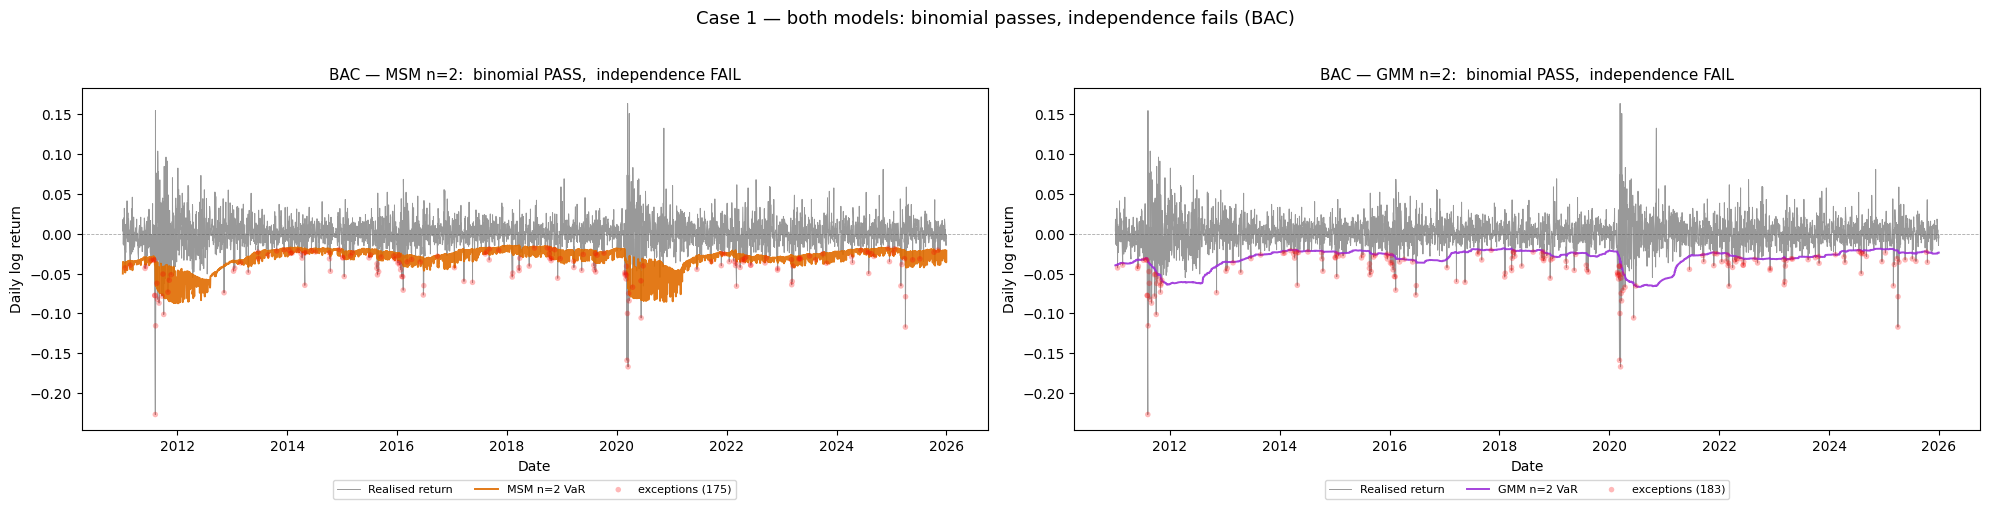

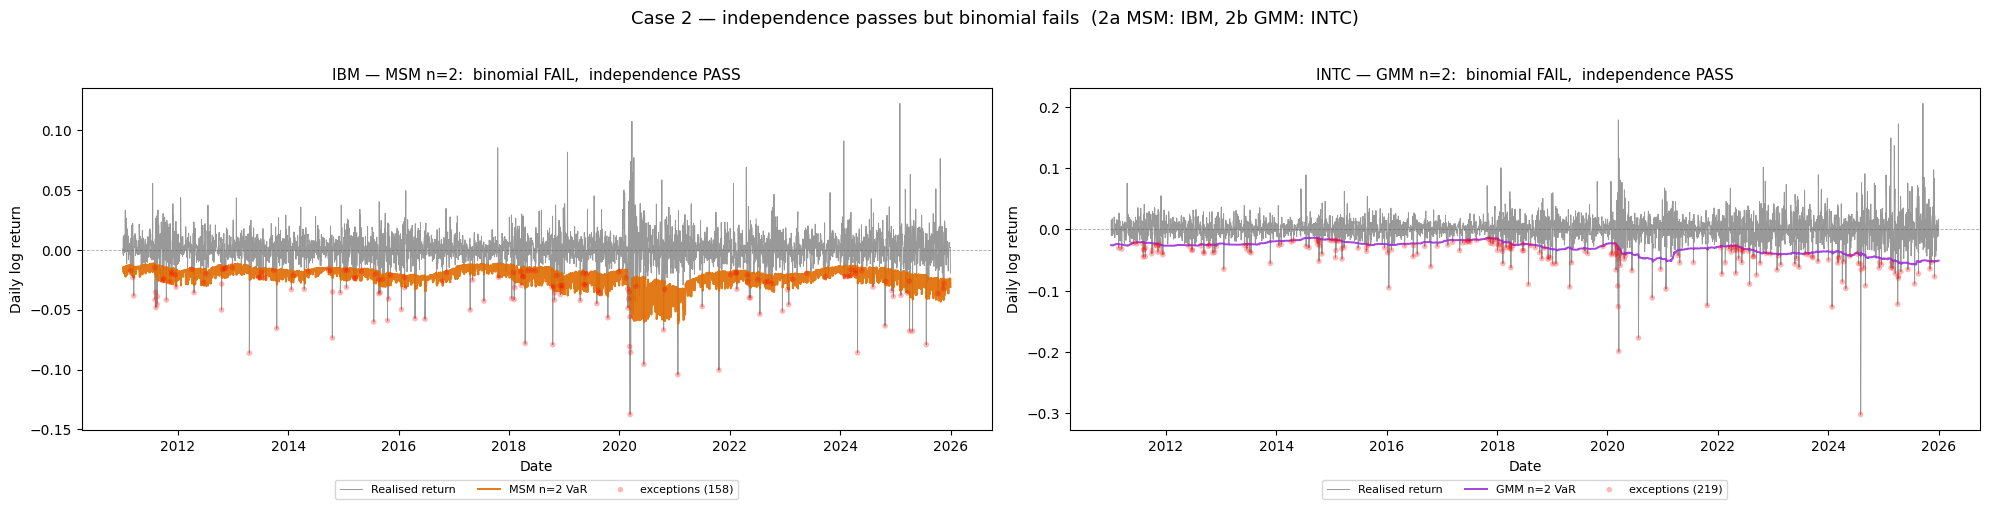

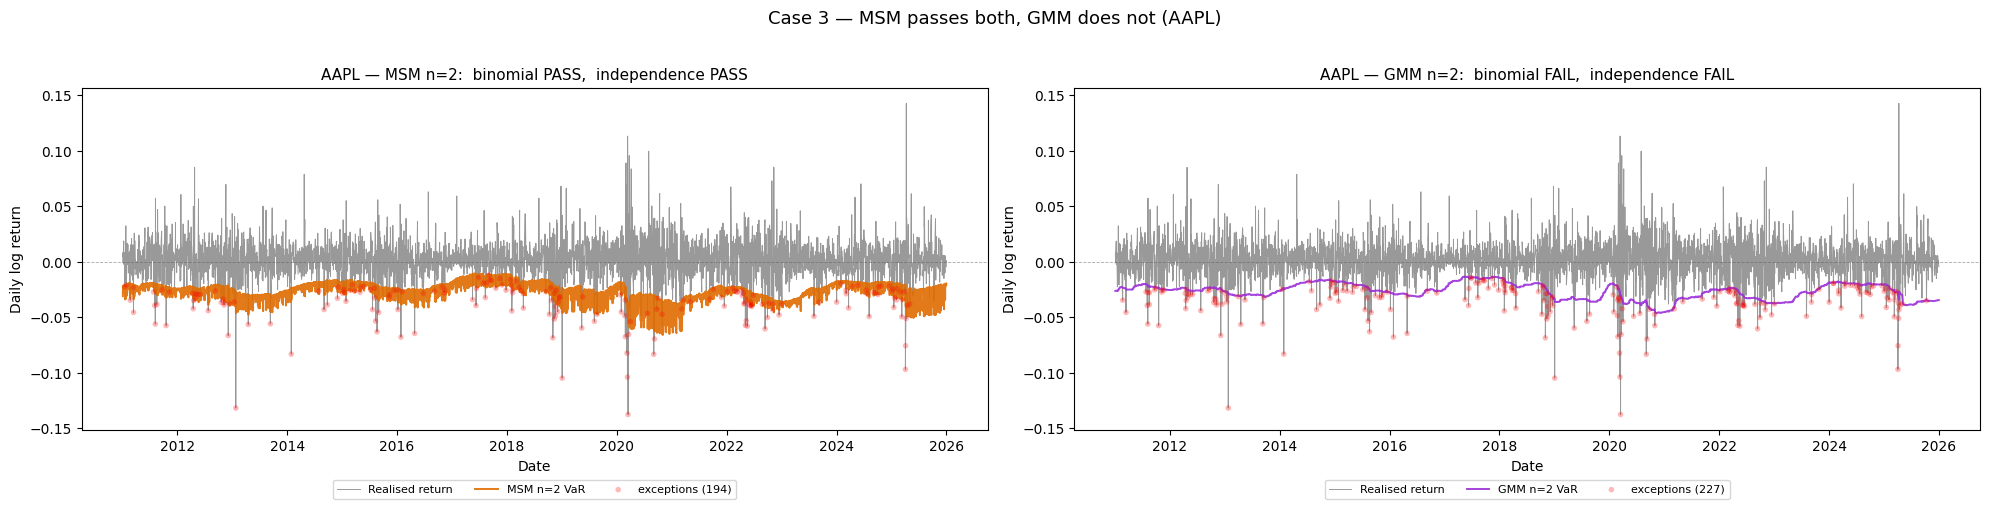

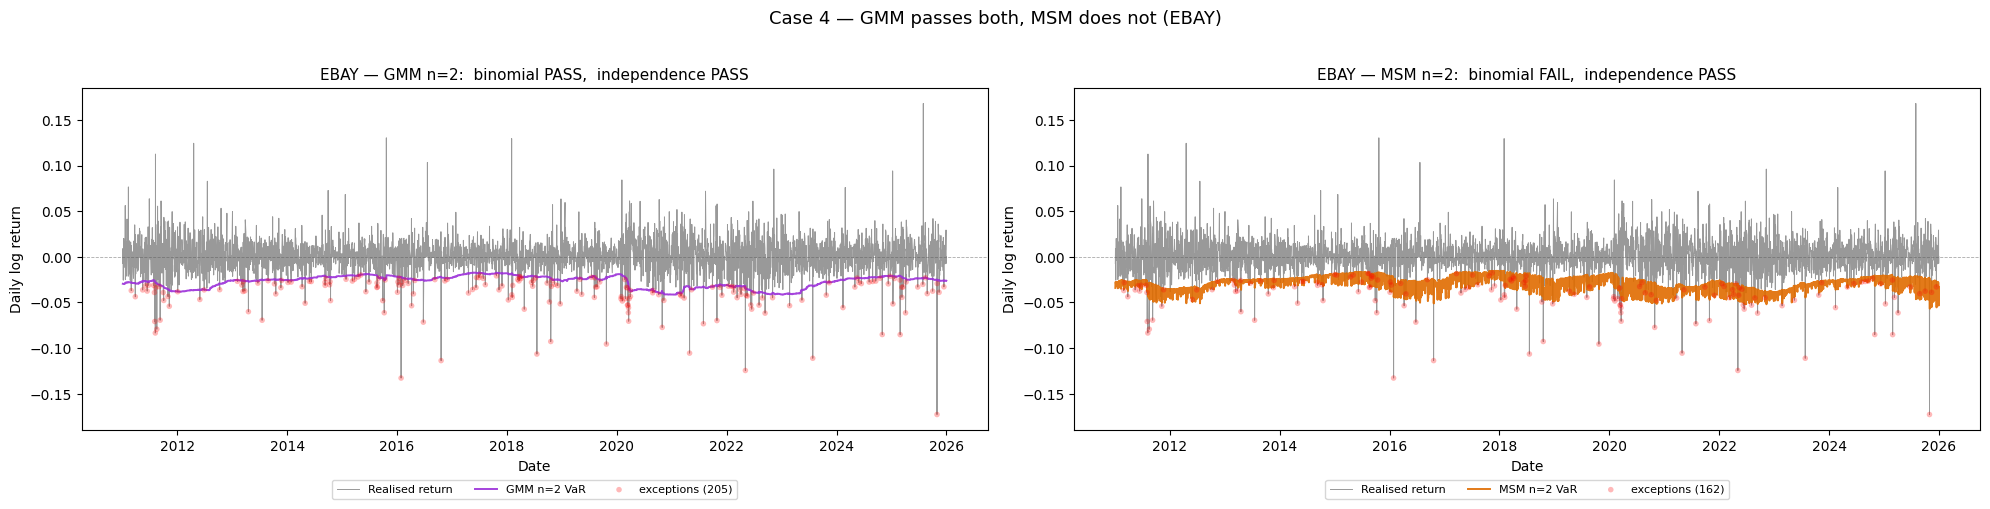

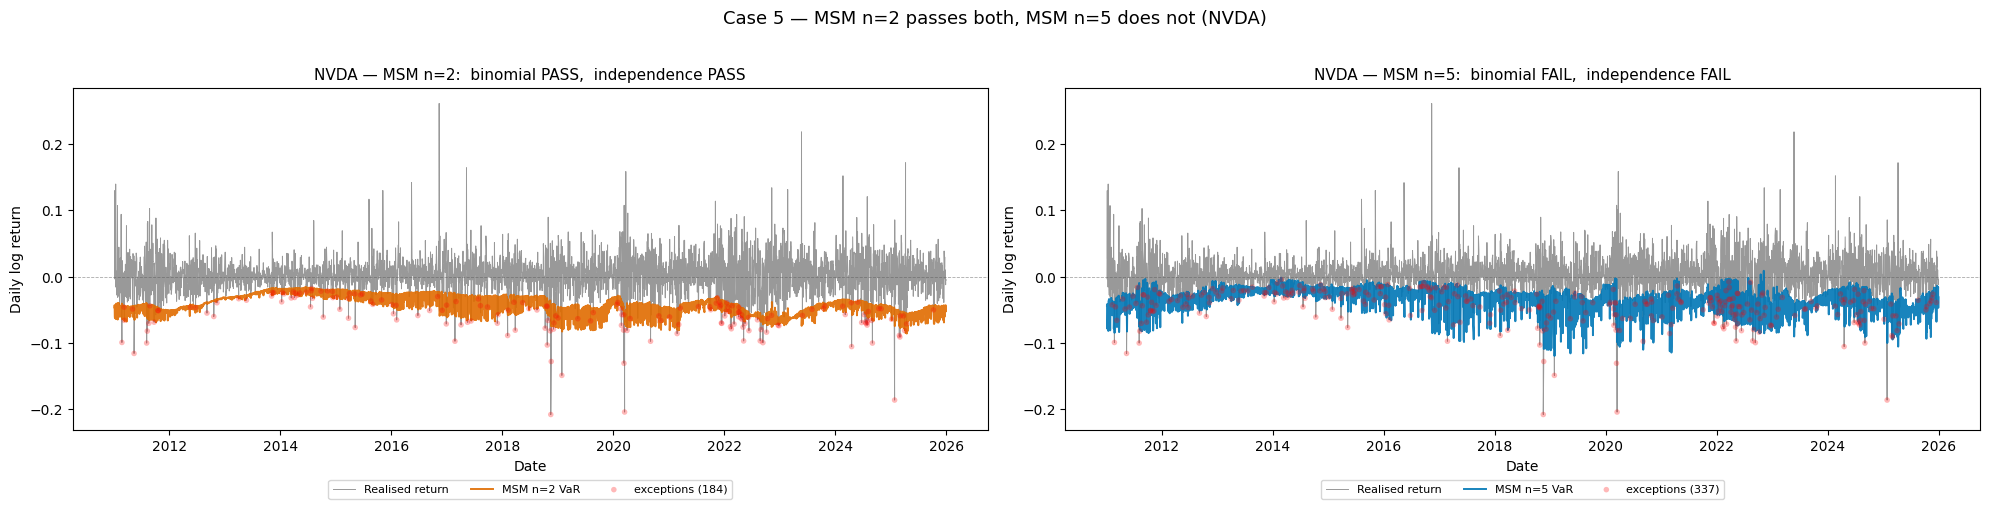

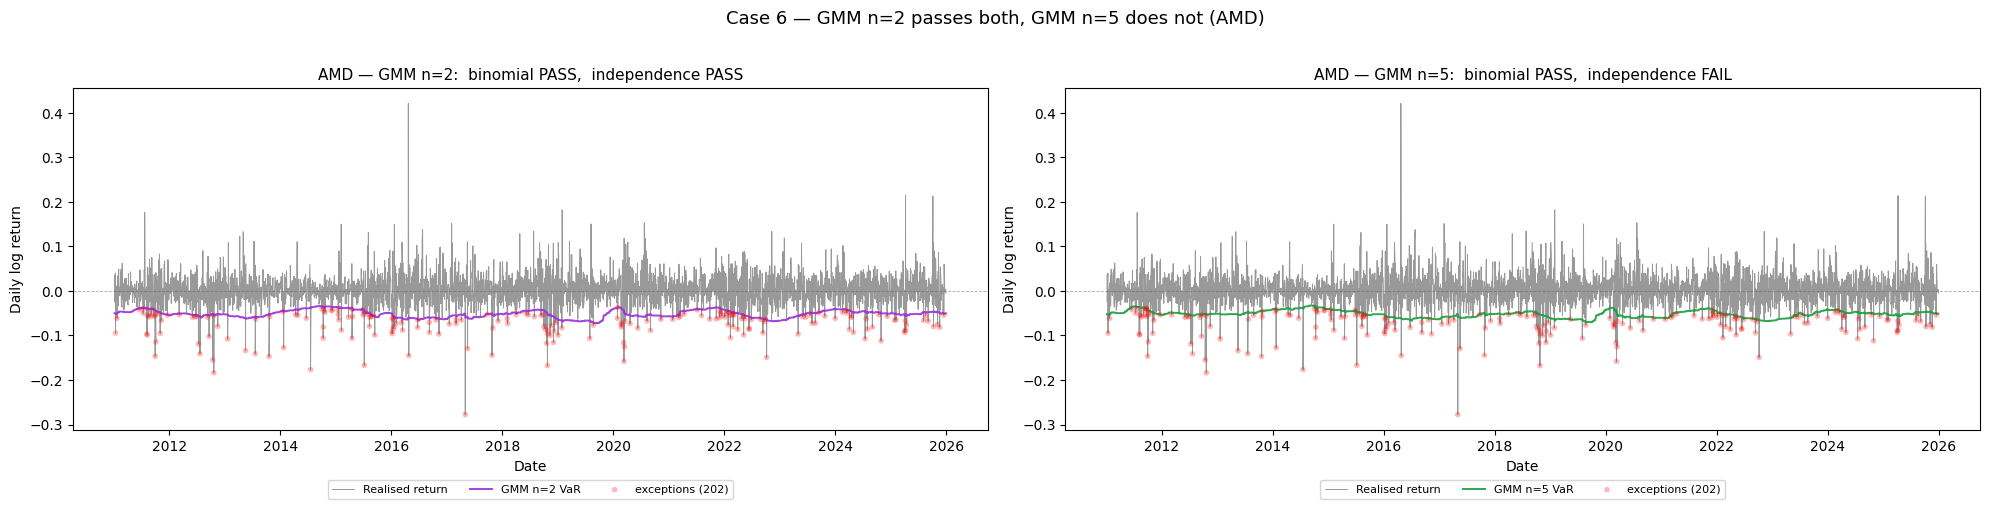

In [3]:
def draw(ax, tk, f, model, n, colour, label):
    sub = feat[f][feat[f]['ticker'] == tk].sort_values('date')
    means, stds, weights = fs._mixture_matrices(sub, model, n)
    var = np.array([quantile_bisection(gaussian_mixture_cdf, ALPHA, -1.0, 1.0,
                                        means[k], stds[k], weights[k])
                    for k in range(len(sub))])
    dates = pd.to_datetime(sub['date'].to_numpy())
    realized = sub['realized_return'].to_numpy()
    res = Backtester(realized, var, ALPHA).test()
    exc = realized < var
    ax.plot(dates, realized, color=RET_COLOR, alpha=0.6, linewidth=0.7,
            label='Realised return', zorder=2)
    ax.plot(dates, var, color=colour, alpha=0.9, linewidth=1.4,
            label=f'{label} VaR', zorder=3)
    ax.scatter(dates[exc], realized[exc], color=EXC_COLOR, alpha=0.28, s=16,
               edgecolors='none', zorder=4, label=f'exceptions ({int(exc.sum())})')
    ax.axhline(0, color='#aaaaaa', linewidth=0.6, linestyle='--', zorder=1)
    b = 'PASS' if res['binomial'] else 'FAIL'
    i = 'PASS' if res['independence_simple'] else 'FAIL'
    ax.set_title(f'{tk} — {label}:  binomial {b},  independence {i}', fontsize=11)
    ax.set_xlabel('Date'); ax.set_ylabel('Daily log return')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=8)

for title, panels in CASES:
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    for ax, spec in zip(axes, panels):
        draw(ax, *spec)
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()